In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [41]:
from ScOPE.matching import MatchingMethods
from ScOPE.matrix import Matrix
from ScOPE import Compressor
from ScOPE import Distance

In [42]:
np.random.seed(4112345)

### Generator for samples

In [43]:
def generate_samples(x:np.ndarray, y:np.ndarray, samples:int=5):
    classes:np.ndarray = np.unique(y)
    for index in range(len(x)):
        test_y:np.ndarray = y[index]
        test_x = x[index]
        kw_samples:list = []
        for classIndex in range(len(classes)):
            mask:np.ndarray = np.where(y == classes[classIndex])[0]
            while True:
                random_index:np.ndarray = np.random.choice(mask, size=samples, replace=True)
                if index not in random_index:
                    break
            kw_samples.append(x[random_index])
        yield test_x, kw_samples, test_y

### Gaussian Function

In [44]:
def gauss(x:np.ndarray) -> np.ndarray:
    sigma:float = 0.12
    return np.exp(-0.5 * np.square((x/sigma)))

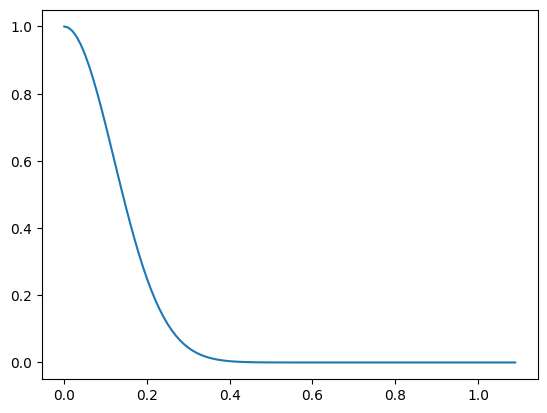

In [45]:
test = np.arange(0, 1.1, 0.01)
gauss_samples = gauss(test)
plt.plot(test, gauss_samples)
plt.show()

### Eval Function

In [46]:
def evaluate(gen) -> tuple:
    all_y_true:list = []
    all_y_pred:list = []
    for test in gen:
        temp_x, kw_samples, test_y = test
        all_distances = gauss(matrix.get_matrix(temp_x, kw_samples))
        classification:np.ndarray = np.zeros(shape=(len(all_distances)), dtype=np.float32)
        for index, x in enumerate(all_distances):
            query:np.ndarray = x[-1]
            samples:np.ndarray = x[:-1]
            for index_s, sample in enumerate(samples):
                mm = MatchingMethods(query, sample)
                classification[index] += mm.dice()
        predicted_class = classification.argmin()
        all_y_true.append(test_y)
        all_y_pred.append(predicted_class)
    return all_y_true, all_y_pred

### CF Matrix

In [47]:
def confmatrix(y_true:list, y_pred:list) -> None:
    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay.from_predictions(y_true=y_true,
                                                   y_pred=y_pred,
                                                   ax=ax,
                                                   normalize='true',
                                                   cmap='Blues')
    plt.show()

### Set model

In [48]:
compressor = Compressor('bz2')
distance = Distance('ncd')
matrix = Matrix(compressor, distance, append_type='text_as_array')

### Clintox test

In [49]:
SMILES_COLUMN:str = 'smiles'
LABEL_COLUMN:str = 'FDA_APPROVED'
FILE_PATH:str = 'clintox.csv'
dataF:pd.DataFrame = pd.read_csv(FILE_PATH)
dataF.head()

,smiles,FDA_APPROVED,CT_TOX
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,1,0
1,[C@@H]1([C@@H]([C@@H]([C@H]([C@@H]([C@@H]1Cl)C...,1,0
2,[C@H]([C@@H]([C@@H](C(=O)[O-])O)O)([C@H](C(=O)...,1,0
3,[H]/[NH+]=C(/C1=CC(=O)/C(=C\C=c2ccc(=C([NH3+])...,1,0
4,[H]/[NH+]=C(\N)/c1ccc(cc1)OCCCCCOc2ccc(cc2)/C(...,1,0


In [50]:
X = dataF[SMILES_COLUMN].values
Y = dataF[LABEL_COLUMN].values

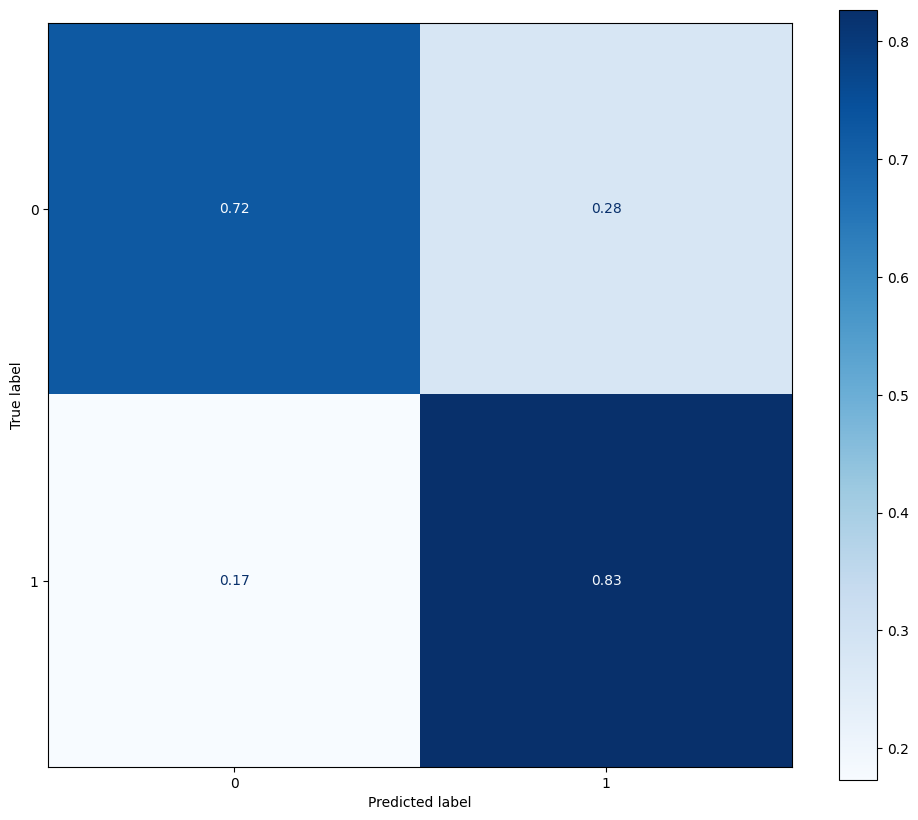

In [51]:
tests: list = generate_samples(X, Y, samples=5)
y_true, y_pred = evaluate(tests)
confmatrix(y_true, y_pred)

### Test BBBP

In [52]:
SMILES_COLUMN:str = 'smiles'
LABEL_COLUMN:str = 'p_np'
FILE_PATH:str = 'BBBP.csv'
dataF:pd.DataFrame = pd.read_csv(FILE_PATH)
dataF.head()

,num,name,p_np,smiles
0,1,Propanolol,1,[Cl].CC(C)NCC(O)COc1cccc2ccccc12
1,2,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2,3,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...
3,4,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
4,5,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...


In [53]:
X = dataF[SMILES_COLUMN].values
Y = dataF[LABEL_COLUMN].values

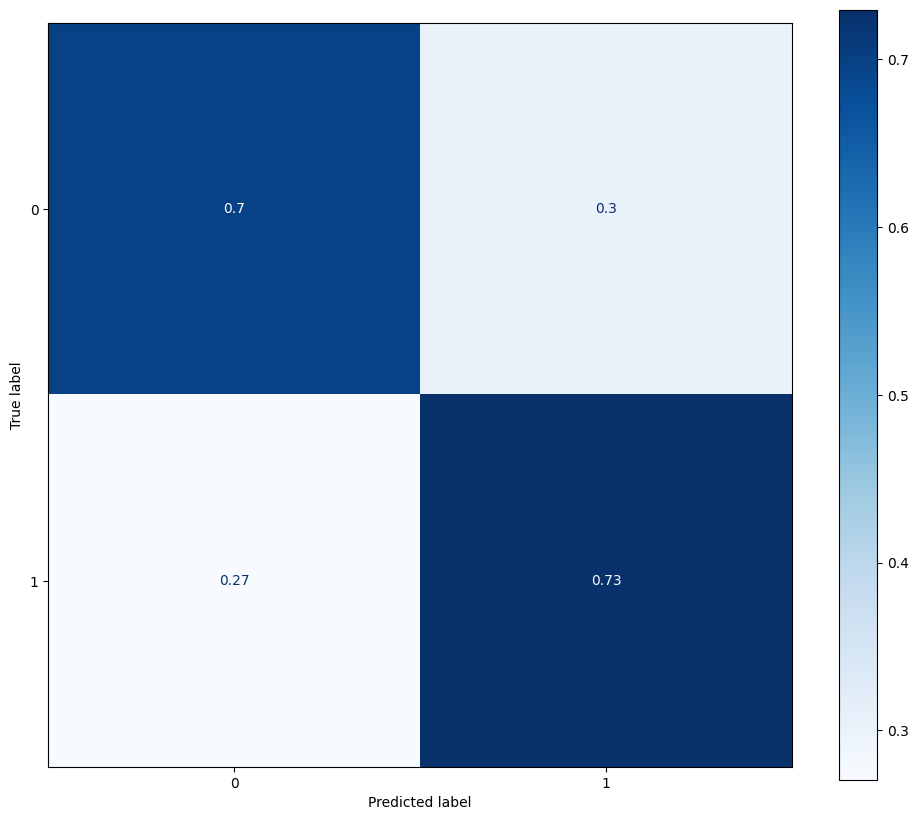

In [55]:
tests: list = generate_samples(X, Y, samples=10)
y_true, y_pred = evaluate(tests)
confmatrix(y_true, y_pred)

### Test BACE

In [56]:
SMILES_COLUMN:str = 'smiles'
LABEL_COLUMN:str = 'Class'
FILE_PATH:str = 'bace.csv'
dataF:pd.DataFrame = pd.read_csv(FILE_PATH)
dataF.head()

,smiles,CID,Class,Model,pIC50,MW,AlogP,HBA,HBD,RB,...,PEOE6 (PEOE6),PEOE7 (PEOE7),PEOE8 (PEOE8),PEOE9 (PEOE9),PEOE10 (PEOE10),PEOE11 (PEOE11),PEOE12 (PEOE12),PEOE13 (PEOE13),PEOE14 (PEOE14),canvasUID
0,O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...,BACE_1,1,Train,9.154901,431.56979,4.4014,3,2,5,...,53.205711,78.640335,226.85541,107.43491,37.133846,0.000000,7.980170,0.0,0.000000,1
1,Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...,BACE_2,1,Train,8.853872,657.81073,2.6412,5,4,16,...,73.817162,47.171600,365.67694,174.07675,34.923889,7.980170,24.148668,0.0,24.663788,2
2,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,BACE_3,1,Train,8.698970,591.74091,2.5499,4,3,11,...,70.365707,47.941147,192.40652,255.75255,23.654478,0.230159,15.879790,0.0,24.663788,3
3,S1(=O)(=O)C[C@@H](Cc2cc(O[C@H](COCC)C(F)(F)F)c...,BACE_4,1,Train,8.698970,591.67828,3.1680,4,3,12,...,56.657166,37.954151,194.35304,202.76335,36.498634,0.980913,8.188327,0.0,26.385181,4
4,S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...,BACE_5,1,Train,8.698970,629.71283,3.5086,3,3,11,...,78.945702,39.361153,179.71288,220.46130,23.654478,0.230159,15.879790,0.0,26.100143,5


In [57]:
X = dataF[SMILES_COLUMN].values
Y = dataF[LABEL_COLUMN].values

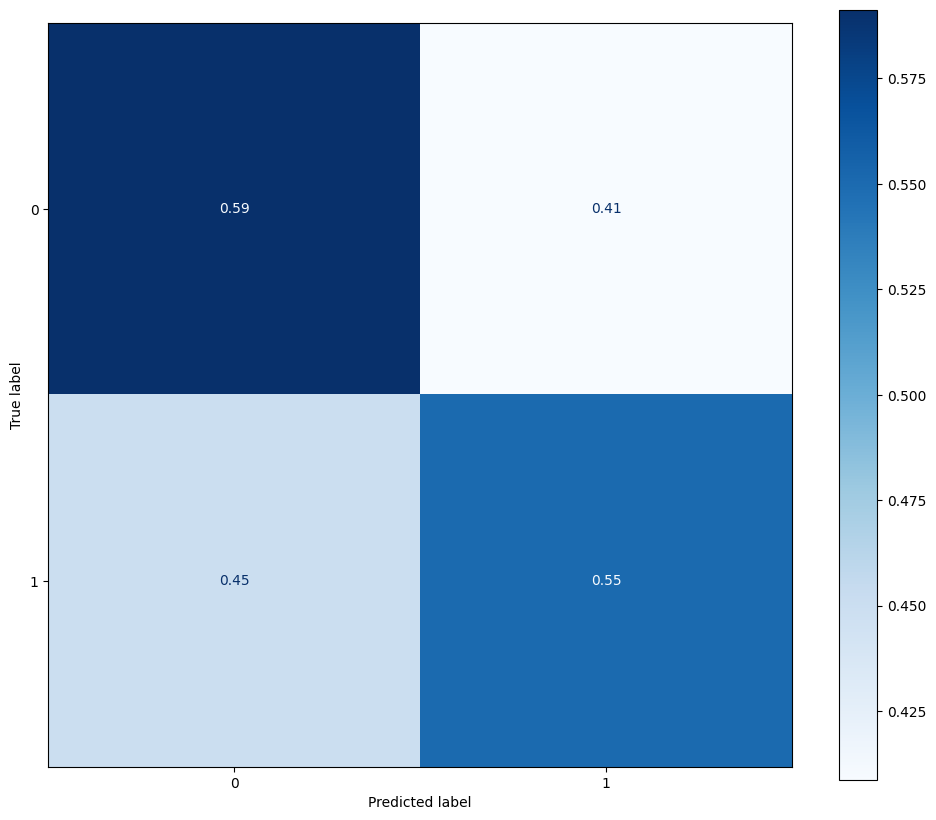

In [61]:
tests: list = generate_samples(X, Y, samples=10)
y_true, y_pred = evaluate(tests)
confmatrix(y_true, y_pred)

### Test HIV Active

In [62]:
SMILES_COLUMN:str = 'smiles'
LABEL_COLUMN:str = 'HIV_active'
FILE_PATH:str = 'HIV.csv'
dataF:pd.DataFrame = pd.read_csv(FILE_PATH)
dataF.dropna(inplace=True)
dataF.head()

,smiles,activity,HIV_active
0,CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)...,CI,0
1,C(=Cc1ccccc1)C1=[O+][Cu-3]2([O+]=C(C=Cc3ccccc3...,CI,0
2,CC(=O)N1c2ccccc2Sc2c1ccc1ccccc21,CI,0
3,Nc1ccc(C=Cc2ccc(N)cc2S(=O)(=O)O)c(S(=O)(=O)O)c1,CI,0
4,O=S(=O)(O)CCS(=O)(=O)O,CI,0


In [63]:
X = dataF[SMILES_COLUMN].values
Y = dataF[LABEL_COLUMN].values

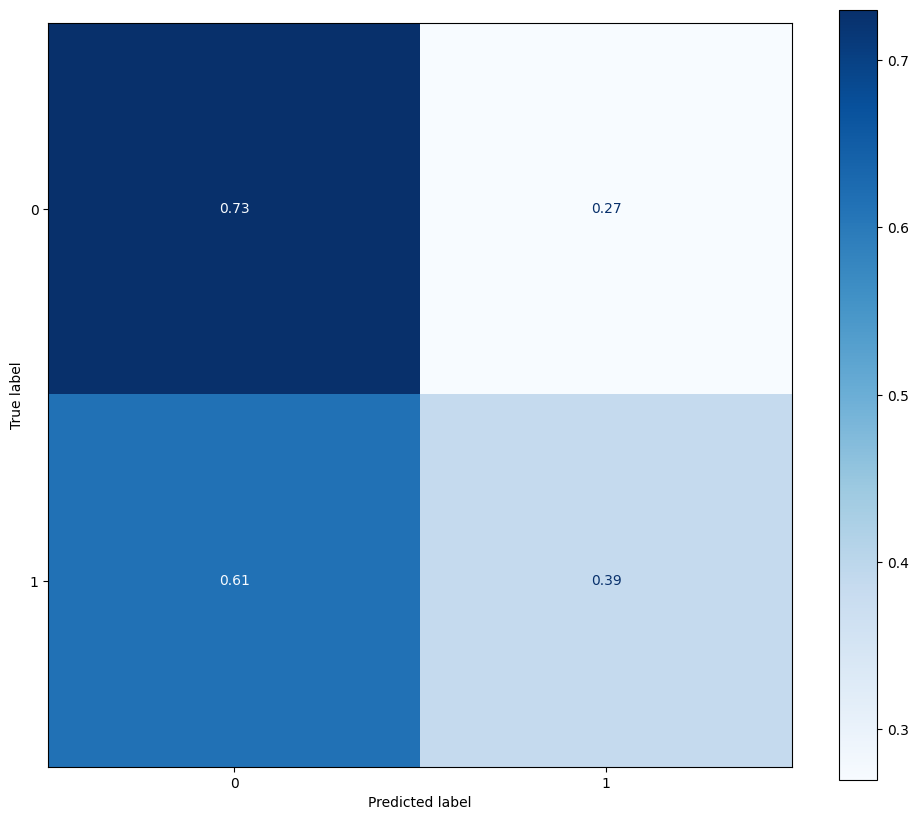

In [64]:
tests: list = generate_samples(X, Y, samples=10)
y_true, y_pred = evaluate(tests)
confmatrix(y_true, y_pred)